In [456]:
import numpy as np
import tkinter as tk
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import struct

In [457]:
black=      [0, 0, 0]
red=        [255, 0, 0]
green=      [0, 255, 0]
blue=       [0, 0, 255]
cyan=       [0, 255, 255]
pink=       [255, 0, 255]
yellow=     [255, 255, 0]
white=      [255, 255, 255]

In [458]:
b_black=    [0, 0, 0]
b_red=      [0, 0, 1]
b_green=    [0, 1, 0]
b_blue=     [0, 1, 1]
b_cyan=     [1, 0, 0]
b_pink=     [1, 0, 1]
b_yellow=   [1, 1, 0]
b_white=    [1, 1, 1]

In [459]:
#Funnciones de graficacion de las matices

#Mostrar la imagen en una ventana de tkinter
def mostrar_img(ruta_imagen, escala=1, pad_x=20, pad_y=20):
    ventana = tk.Tk()
    ventana.title("Visor de Imágenes")
    ventana.resizable(False, False)
    try:
        imagen_original = Image.open(ruta_imagen)

        etiqueta_imagen = tk.Label(ventana)
        etiqueta_imagen.pack(padx=pad_x, pady=pad_y)

        # escala: float >0 o int. resample por defecto Image.NEAREST (útil para estampa QR)
        def _show(escala_local=1, resample=Image.NEAREST):
            img = imagen_original
            if escala_local != 1:
                w, h = img.size
                new_size = (max(1, int(w * escala_local)), max(1, int(h * escala_local)))
                img = img.resize(new_size, resample=resample)

            imagen_tk = ImageTk.PhotoImage(img)
            # Reemplazar imagen en la etiqueta existente para que no se acumulen widgets
            etiqueta_imagen.configure(image=imagen_tk)
            etiqueta_imagen.image = imagen_tk

            # Ajustar tamaño de la ventana al contenido + padding para evitar recortes
            try:
                desired_w = img.size[0] + 2 * pad_x
                desired_h = img.size[1] + 2 * pad_y
                ventana.geometry(f"{desired_w}x{desired_h}")
            except Exception:
                pass
            ventana.update_idletasks()

        _show(escala)

        ventana._show_image_with_scale = _show

    except FileNotFoundError:
        etiqueta_error = tk.Label(ventana, text="Error: No se encontró la imagen.", fg="red")
        etiqueta_error.pack(padx=50, pady=50)
    
    ventana.mainloop()

#Crear la imagen
def crear_img(matriz_rgb):
    if matriz_rgb is None:
        print("Error: La matriz de píxeles no puede ser None.")
        return

    arreglo_pixeles = np.array(matriz_rgb, dtype=np.uint8)

    imagen = Image.fromarray(arreglo_pixeles, 'RGB')

    imagen.save("mi_imagen_generada.png")
    
    return "mi_imagen_generada.png"

#Mostar la imagen con matplotlib
def mostrar_plt(matriz):
    arr = np.array(matriz, dtype=np.uint8)

    if arr.ndim != 3 or arr.shape[2] != 3:
        raise ValueError("La matriz debe tener forma (alto, ancho, 3).")

    plt.figure(figsize=(6, 6))
    plt.imshow(arr, interpolation="nearest")
    plt.axis("off")
    plt.show()

In [460]:
#Black, Red, Green or Blue

def valores_rgb(matriz):
    for i in range(tamaño):
        for j in range(tamaño):
            px= np.random.randint(0,4)
            if px==0:
                matriz[i,j]= [0,0,0]
            elif px==1:
                matriz[i,j]= [255,0,0]
            elif px==2:
                matriz[i,j]= [0,255,0]
            elif px==3:
                matriz[i,j]= [0,0,255]
            
    return matriz

def estampa_qr(matriz, color=black, tamaño=tamaño):
    if tamaño > 14:
        matriz[0:7, 0:7] = [[0, 0, 0]]
        matriz[1:6, 1:6] = [color]
        matriz[2:5, 2:5] = [[0, 0, 0]]

        matriz[tamaño-7:tamaño, 0:7] = [[0, 0, 0]]
        matriz[tamaño-6:tamaño-1, 1:6] = [color]
        matriz[tamaño-5:tamaño-2, 2:5] = [[0, 0, 0]]

        matriz[0:7, tamaño-7:tamaño] = [[0, 0, 0]]
        matriz[1:6, tamaño-6:tamaño-1] = [color]
        matriz[2:5, tamaño-5:tamaño-2] = [[0, 0, 0]]
        return matriz  
    else:
        raise ValueError("El tamaño de la matriz debe ser mayor que 7 para aplicar la estampa QR.")

def qr_data_type(matriz, data_type):
    if type(data_type) is str:
        #matriz[tamaño-1, tamaño-1] = red
        color = red
    elif type(data_type) is int:
        #matriz[tamaño-1, tamaño-1] = green
        color = green
        if data_type < 0:
            color = yellow
    elif type(data_type) is float:
        #matriz[tamaño-1, tamaño-1] = blue
        color = blue

    #elif type(data_type) is binary:
    #    matriz[tamaño-1, tamaño-1] = blue
    return matriz, color


In [461]:
#matriz_usable = np.zeros((tamaño-7, tamaño-7, 3), dtype=np.uint8)
#matriz_base[7:tamaño, 7:tamaño]=matriz_usable

In [462]:
#Codificar datos a binario a colores

def a_binario(data):
    if isinstance(data, str):
        return ''.join(format(ord(c), '08b') for c in data)
    elif isinstance(data, int):
        return format(data if data >= 0 else abs(data), 'b')
    elif isinstance(data, float):
        return ''.join(format(b, '08b') for b in struct.pack('!d', data))
    else:
        raise ValueError("Tipo de dato no soportado. Use str, int o float.")

def groups(data):
    pixels = []
    for i in range(0, len(data), 3):
        pixels.append(data[i:i + 3])
    return pixels

def encode(data):
    colours = []
    for tbyte in data:
        if tbyte == '000':
            colours.append(black)
        elif tbyte == '001':
            colours.append(red)
        elif tbyte == '010':
            colours.append(green)
        elif tbyte == '011':
            colours.append(blue)
        elif tbyte == '100':
            colours.append(cyan)
        elif tbyte == '101':
            colours.append(pink)
        elif tbyte == '110':
            colours.append(yellow)
        elif tbyte == '111':
            colours.append(white)
        if len(tbyte) < 3:
            if len(tbyte)==1:
                if tbyte == '0':
                    colours.append(black)
                elif tbyte == '1':
                    colours.append(white)
            elif len(tbyte)==2:
                if tbyte == '00':
                    colours.append(red)
                elif tbyte == '01':
                    colours.append(green)
                elif tbyte == '10':
                    colours.append(blue)
                elif tbyte == '11':
                    colours.append(yellow)
    return colours

In [463]:
#Aplicar colores a la matriz
def apply_colours(matriz, colours):
    if len(colours) > (tamaño - 7) * (tamaño - 7):
        raise ValueError("La cantidad de colores excede el tamaño disponible en la matriz.")
    
    index = 0
    for i in range(7, tamaño):
        for j in range(7, tamaño):
            if index < len(colours):
                matriz[i, j] = colours[index]
                index += 1
            else:
                break
    return matriz

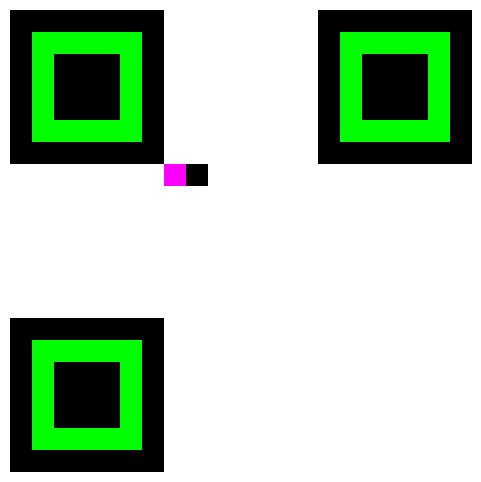

In [467]:
tamaño = 21
data= 10

matriz = np.full((tamaño, tamaño, 3), [255, 255, 255], dtype=np.uint8)
matriz, color = qr_data_type(matriz, data)
matriz_base = estampa_qr(matriz, color, tamaño)

data= encode(groups(a_binario(data)))


apply_colours(matriz_base, data)
mostrar_plt(matriz_base)